# 3.4 Feature Importance Analysis

This notebook identifies which of the 256 latent dimensions are most important for predicting SBR pathology targets.

## Research Questions:
1. **Which latent dimensions are most predictive of SBR_PC1, PC2, PC3?**
2. **Are there common dimensions across all targets?**
3. **Do different targets rely on different features?**

## Methods:
- Extract Ridge regression coefficients (feature weights)
- Rank features by absolute coefficient magnitude
- Analyze top contributing dimensions
- Visualize feature importance patterns

## Interpretation:
- **Large positive coefficient** → Feature increases target value
- **Large negative coefficient** → Feature decreases target value
- **Small coefficient** → Feature has little predictive power

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
# Target variables
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']

# Image feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]

# SBR columns for PCA
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Model parameters
ALPHA = 10.0
RANDOM_STATE = 42
TOP_N = 20  # Top N features to display

print(f"Number of latent features: {len(FEATURE_COLS)}")
print(f"Top N features to analyze: {TOP_N}")

Number of latent features: 256
Top N features to analyze: 20


### 1.3 Load and Prepare Data

In [3]:
# Load merged clinical/demographic data
df_merged = pd.read_csv('output/merged_data.csv')
print(f"Merged clinical data shape: {df_merged.shape}")

# Load train set latent vectors (larger test set)
latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
df_latent = pd.read_csv(latent_file)
print(f"Train set latent vectors loaded: {df_latent.shape}")

# Merge and prepare data
df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')

# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]
df_combined = df_with_sbr.copy()

# Select best visit per patient
# def select_best_visit(group):
#     valid_rows = group.dropna(subset=['AGE_AT_VISIT', 'SEX', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3'])
#     if len(valid_rows) == 0:
#         return None
#     if 'EVENT_ID' in valid_rows.columns:
#         priority = {'SC': 0, 'BL': 1, 'V01': 2, 'V02': 3}
#         valid_rows = valid_rows.copy()
#         valid_rows['priority'] = valid_rows['EVENT_ID'].map(priority).fillna(99)
#         return valid_rows.sort_values('priority').iloc[0:1]
#     return valid_rows.iloc[0:1]

# df_final = df_combined.groupby('PATNO', group_keys=False).apply(select_best_visit)
# df_final = df_final.dropna(subset=['PATNO']).reset_index(drop=True)

df_final = df_combined.dropna(subset=['PATNO']).reset_index(drop=True)

print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Merged clinical data shape: (41816, 42)
Train set latent vectors loaded: (2340, 260)

Final dataset: (6630, 304)
Unique patients: 1406


### 1.4 Extract and Standardize Features

In [4]:
# Extract features and targets
X_features = df_final[FEATURE_COLS].values
Y_targets = df_final[TARGETS].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Features shape: {X_scaled.shape}")
print(f"Targets shape: {Y_targets.shape}")
print(f"\nFeature standardization check:")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")

Features shape: (6630, 256)
Targets shape: (6630, 3)

Feature standardization check:
  Mean: 0.000000
  Std: 1.000000


## Section 2: Train Models and Extract Coefficients

### 2.1 Train Ridge Models for Each Target

In [5]:
# Dictionary to store coefficients
coefficients_dict = {}
models_dict = {}

print("Training Ridge models for each target...\n")

for idx, target_name in enumerate(TARGETS):
    print(f"Training model for {target_name}...")
    
    # Extract target
    y = Y_targets[:, idx]
    
    # Train Ridge model
    model = Ridge(alpha=ALPHA, random_state=RANDOM_STATE)
    model.fit(X_scaled, y)
    
    # Store model and coefficients
    models_dict[target_name] = model
    coefficients_dict[target_name] = model.coef_
    
    # Print model info
    train_r2 = model.score(X_scaled, y)
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    print(f"  Coefficient range: [{model.coef_.min():.4f}, {model.coef_.max():.4f}]")
    print()

print("✓ All models trained successfully!")

Training Ridge models for each target...

Training model for SBR_PC1...
  Train R²: 0.8258
  Intercept: -0.0000
  Coefficient range: [-0.5033, 0.2852]

Training model for SBR_PC2...
  Train R²: 0.7700
  Intercept: -0.0000
  Coefficient range: [-0.0942, 0.0743]

Training model for SBR_PC3...
  Train R²: 0.6553
  Intercept: -0.0000
  Coefficient range: [-0.0559, 0.0713]

✓ All models trained successfully!


### 2.2 Rank Features by Importance

In [6]:
# Create importance dataframes
importance_dfs = {}

for target_name in TARGETS:
    coefs = coefficients_dict[target_name]
    
    # Create dataframe
    df_importance = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Coefficient': coefs,
        'Abs_Coefficient': np.abs(coefs)
    })
    
    # Sort by absolute coefficient
    df_importance = df_importance.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
    df_importance['Rank'] = range(1, len(df_importance) + 1)
    
    importance_dfs[target_name] = df_importance
    
    # Print top features
    print(f"\n{'='*80}")
    print(f"TOP {TOP_N} FEATURES FOR {target_name}")
    print(f"{'='*80}")
    print(df_importance.head(TOP_N)[['Rank', 'Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))


TOP 20 FEATURES FOR SBR_PC1
 Rank    Feature  Coefficient  Abs_Coefficient
    1  latent_93    -0.503316         0.503316
    2  latent_73    -0.402387         0.402387
    3   latent_5    -0.401070         0.401070
    4 latent_116     0.285159         0.285159
    5 latent_177    -0.222630         0.222630
    6  latent_44     0.148959         0.148959
    7  latent_41    -0.124119         0.124119
    8 latent_187    -0.123607         0.123607
    9  latent_53     0.106823         0.106823
   10  latent_61     0.101876         0.101876
   11 latent_239     0.091398         0.091398
   12  latent_63    -0.090620         0.090620
   13 latent_133    -0.088963         0.088963
   14  latent_86     0.088686         0.088686
   15 latent_213    -0.088507         0.088507
   16 latent_236     0.087251         0.087251
   17  latent_31    -0.086932         0.086932
   18  latent_79    -0.084519         0.084519
   19 latent_253     0.084222         0.084222
   20  latent_92     0.083234  

### 2.3 Analyze Feature Overlap

In [7]:
print("\n" + "="*80)
print("FEATURE OVERLAP ANALYSIS")
print("="*80)

# Get top 20 features for each target
top_features = {}
for target_name in TARGETS:
    top_features[target_name] = set(importance_dfs[target_name].head(TOP_N)['Feature'].values)

# Find common features
common_all = top_features['SBR_PC1'] & top_features['SBR_PC2'] & top_features['SBR_PC3']
common_pc1_pc2 = top_features['SBR_PC1'] & top_features['SBR_PC2']
common_pc1_pc3 = top_features['SBR_PC1'] & top_features['SBR_PC3']
common_pc2_pc3 = top_features['SBR_PC2'] & top_features['SBR_PC3']

print(f"\nCommon top-{TOP_N} features:")
print(f"  All three targets: {len(common_all)} features")
if common_all:
    print(f"    {sorted(common_all)}")

print(f"\n  PC1 & PC2: {len(common_pc1_pc2)} features")
print(f"  PC1 & PC3: {len(common_pc1_pc3)} features")
print(f"  PC2 & PC3: {len(common_pc2_pc3)} features")

# Unique features
unique_pc1 = top_features['SBR_PC1'] - top_features['SBR_PC2'] - top_features['SBR_PC3']
unique_pc2 = top_features['SBR_PC2'] - top_features['SBR_PC1'] - top_features['SBR_PC3']
unique_pc3 = top_features['SBR_PC3'] - top_features['SBR_PC1'] - top_features['SBR_PC2']

print(f"\nUnique top-{TOP_N} features:")
print(f"  PC1 only: {len(unique_pc1)} features")
print(f"  PC2 only: {len(unique_pc2)} features")
print(f"  PC3 only: {len(unique_pc3)} features")


FEATURE OVERLAP ANALYSIS

Common top-20 features:
  All three targets: 2 features
    ['latent_116', 'latent_93']

  PC1 & PC2: 8 features
  PC1 & PC3: 4 features
  PC2 & PC3: 5 features

Unique top-20 features:
  PC1 only: 10 features
  PC2 only: 9 features
  PC3 only: 13 features


## Section 3: Visualizations

### 3.1 Top Features Bar Plot

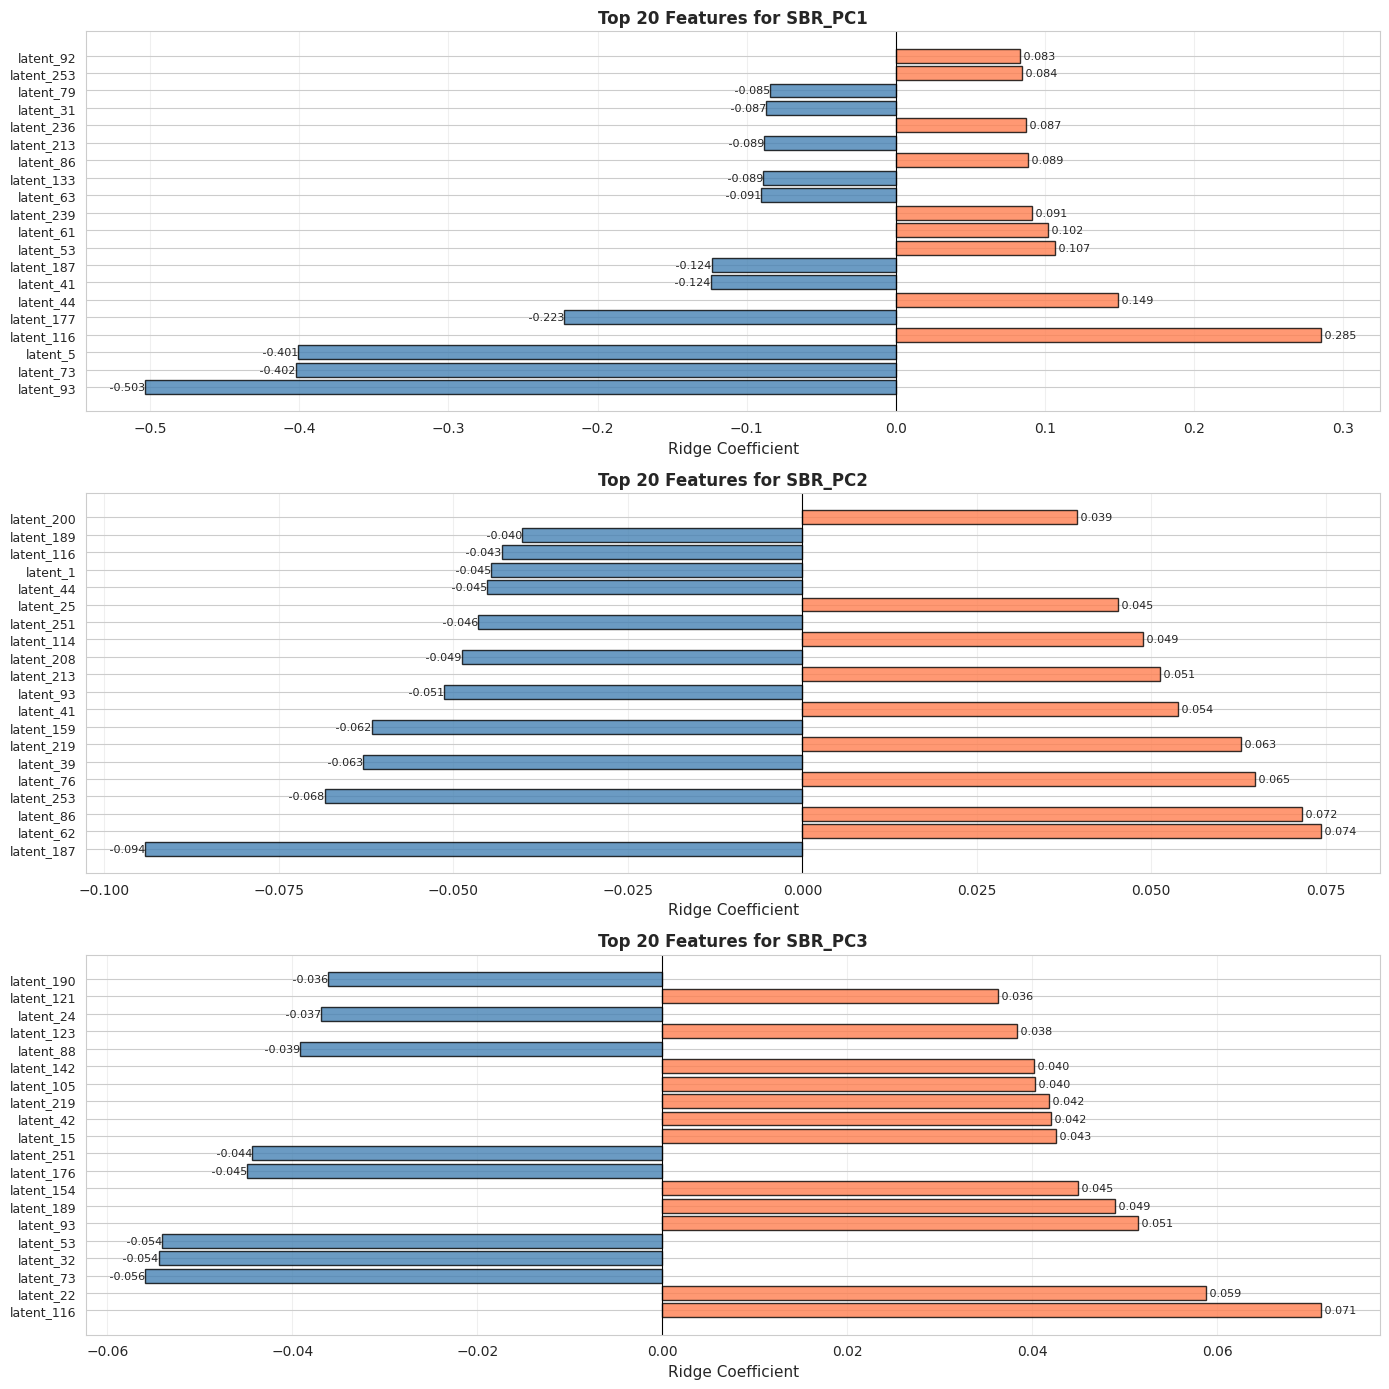

Plot saved to: output/feature_importance_top20.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for idx, target_name in enumerate(TARGETS):
    df_imp = importance_dfs[target_name].head(TOP_N)
    
    # Color by sign
    colors = ['coral' if x > 0 else 'steelblue' for x in df_imp['Coefficient']]
    
    axes[idx].barh(range(len(df_imp)), df_imp['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
    axes[idx].set_yticks(range(len(df_imp)))
    axes[idx].set_yticklabels(df_imp['Feature'], fontsize=9)
    axes[idx].set_xlabel('Ridge Coefficient', fontsize=11)
    axes[idx].set_title(f'Top {TOP_N} Features for {target_name}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # Add value labels
    for i, (feat, coef) in enumerate(zip(df_imp['Feature'], df_imp['Coefficient'])):
        axes[idx].text(coef, i, f' {coef:.3f}', va='center', 
                      ha='left' if coef > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('output/feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/feature_importance_top20.png")

### 3.2 Coefficient Distribution

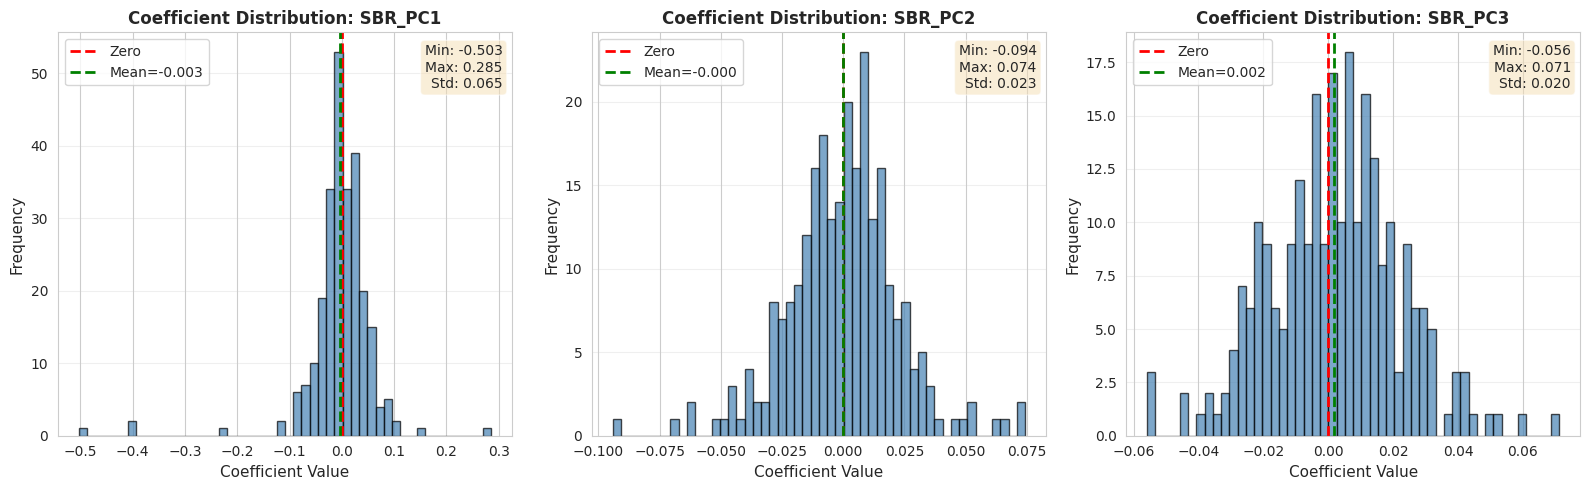

Plot saved to: output/coefficient_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, target_name in enumerate(TARGETS):
    coefs = coefficients_dict[target_name]
    
    axes[idx].hist(coefs, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    axes[idx].axvline(x=coefs.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean={coefs.mean():.3f}')
    axes[idx].set_xlabel('Coefficient Value', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Coefficient Distribution: {target_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    stats_text = f"Min: {coefs.min():.3f}\nMax: {coefs.max():.3f}\nStd: {coefs.std():.3f}"
    axes[idx].text(0.98, 0.97, stats_text, transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('output/coefficient_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/coefficient_distribution.png")

### 3.3 Feature Importance Heatmap

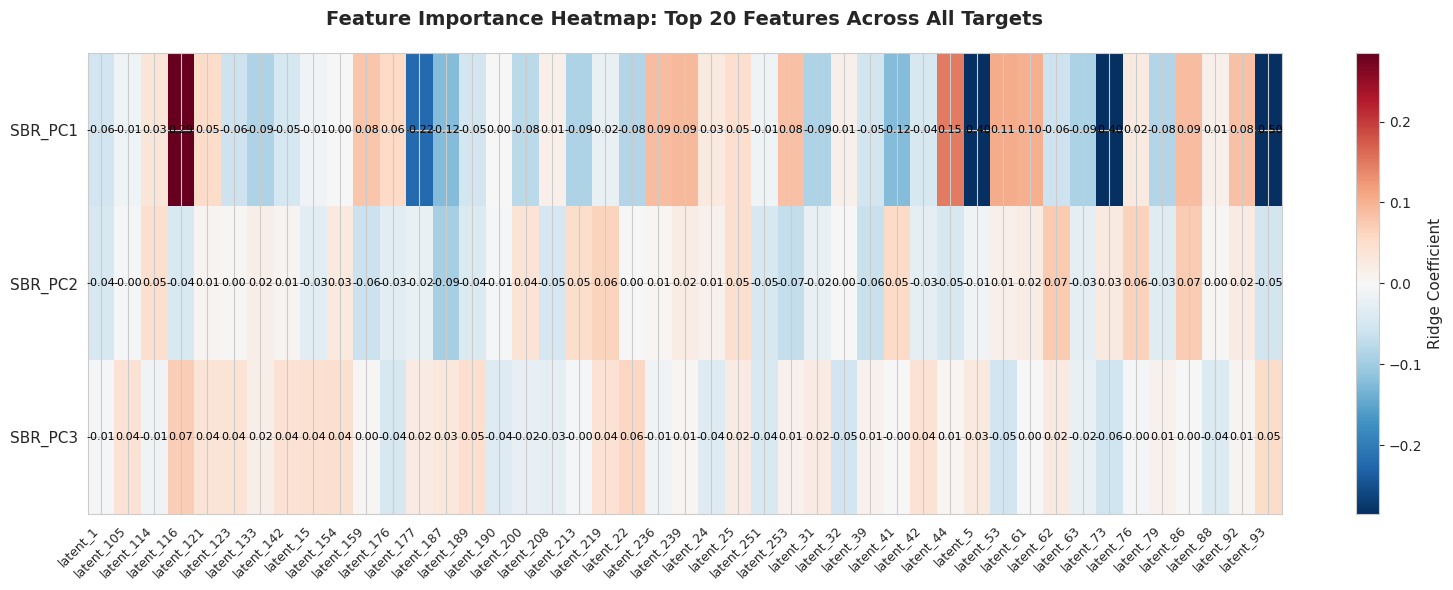

Plot saved to: output/feature_importance_heatmap.png


In [10]:
# Create matrix of top features across all targets
all_top_features = set()
for target_name in TARGETS:
    all_top_features.update(importance_dfs[target_name].head(TOP_N)['Feature'].values)

all_top_features = sorted(list(all_top_features))

# Create coefficient matrix
coef_matrix = []
for target_name in TARGETS:
    row = []
    for feature in all_top_features:
        coef = importance_dfs[target_name][importance_dfs[target_name]['Feature'] == feature]['Coefficient'].values
        row.append(coef[0] if len(coef) > 0 else 0)
    coef_matrix.append(row)

coef_matrix = np.array(coef_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(coef_matrix, cmap='RdBu_r', aspect='auto', vmin=-coef_matrix.max(), vmax=coef_matrix.max())

# Set ticks and labels
ax.set_xticks(range(len(all_top_features)))
ax.set_xticklabels(all_top_features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS, fontsize=11)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Ridge Coefficient', fontsize=11)

# Add values to cells
for i in range(len(TARGETS)):
    for j in range(len(all_top_features)):
        text = ax.text(j, i, f'{coef_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

ax.set_title(f'Feature Importance Heatmap: Top {TOP_N} Features Across All Targets', 
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('output/feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/feature_importance_heatmap.png")

### 3.4 Cumulative Importance

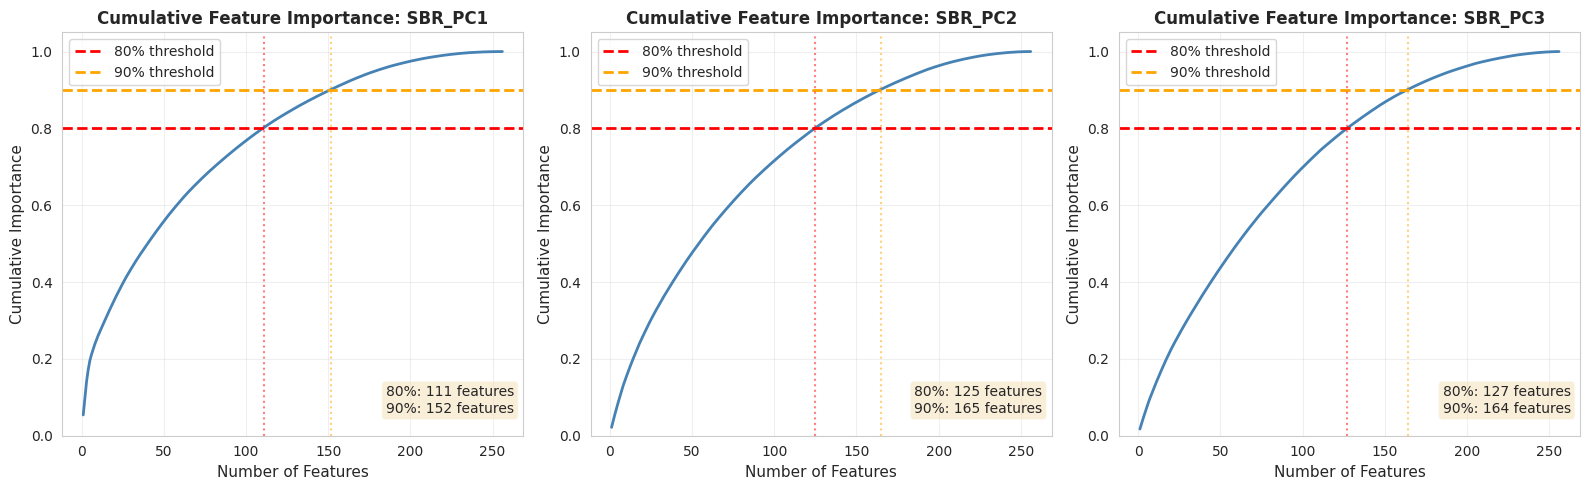

Plot saved to: output/cumulative_feature_importance.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, target_name in enumerate(TARGETS):
    df_imp = importance_dfs[target_name].copy()
    
    # Calculate cumulative importance (using absolute values)
    df_imp['Cumulative_Importance'] = df_imp['Abs_Coefficient'].cumsum() / df_imp['Abs_Coefficient'].sum()
    
    # Plot
    axes[idx].plot(range(1, len(df_imp) + 1), df_imp['Cumulative_Importance'], 
                   linewidth=2, color='steelblue')
    axes[idx].axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')
    axes[idx].axhline(y=0.9, color='orange', linestyle='--', linewidth=2, label='90% threshold')
    
    # Find number of features needed for 80% and 90%
    n_80 = (df_imp['Cumulative_Importance'] >= 0.8).idxmax() + 1
    n_90 = (df_imp['Cumulative_Importance'] >= 0.9).idxmax() + 1
    
    axes[idx].axvline(x=n_80, color='red', linestyle=':', alpha=0.5)
    axes[idx].axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
    
    axes[idx].set_xlabel('Number of Features', fontsize=11)
    axes[idx].set_ylabel('Cumulative Importance', fontsize=11)
    axes[idx].set_title(f'Cumulative Feature Importance: {target_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1.05])
    
    # Add text
    text = f"80%: {n_80} features\n90%: {n_90} features"
    axes[idx].text(0.98, 0.05, text, transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='bottom', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('output/cumulative_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/cumulative_feature_importance.png")

## Section 4: Summary and Interpretation

### 4.1 Feature Importance Summary

In [12]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE SUMMARY")
print("="*80)

for target_name in TARGETS:
    df_imp = importance_dfs[target_name].copy()
    df_imp['Cumulative_Importance'] = df_imp['Abs_Coefficient'].cumsum() / df_imp['Abs_Coefficient'].sum()
    
    print(f"\n{target_name}:")
    print(f"  Total features: {len(df_imp)}")
    print(f"  Features with non-zero coefficient: {(df_imp['Coefficient'] != 0).sum()}")
    print(f"  Positive coefficients: {(df_imp['Coefficient'] > 0).sum()}")
    print(f"  Negative coefficients: {(df_imp['Coefficient'] < 0).sum()}")
    
    # Find thresholds
    n_80 = (df_imp['Cumulative_Importance'] >= 0.8).idxmax() + 1
    n_90 = (df_imp['Cumulative_Importance'] >= 0.9).idxmax() + 1
    n_95 = (df_imp['Cumulative_Importance'] >= 0.95).idxmax() + 1
    
    print(f"\n  Features needed for:")
    print(f"    80% importance: {n_80} features ({n_80/len(df_imp)*100:.1f}%)")
    print(f"    90% importance: {n_90} features ({n_90/len(df_imp)*100:.1f}%)")
    print(f"    95% importance: {n_95} features ({n_95/len(df_imp)*100:.1f}%)")
    
    # Top 5 features
    print(f"\n  Top 5 features:")
    for i, row in df_imp.head(5).iterrows():
        print(f"    {row['Feature']}: {row['Coefficient']:.4f}")


FEATURE IMPORTANCE SUMMARY

SBR_PC1:
  Total features: 256
  Features with non-zero coefficient: 256
  Positive coefficients: 129
  Negative coefficients: 127

  Features needed for:
    80% importance: 111 features (43.4%)
    90% importance: 152 features (59.4%)
    95% importance: 180 features (70.3%)

  Top 5 features:
    latent_93: -0.5033
    latent_73: -0.4024
    latent_5: -0.4011
    latent_116: 0.2852
    latent_177: -0.2226

SBR_PC2:
  Total features: 256
  Features with non-zero coefficient: 256
  Positive coefficients: 133
  Negative coefficients: 123

  Features needed for:
    80% importance: 125 features (48.8%)
    90% importance: 165 features (64.5%)
    95% importance: 192 features (75.0%)

  Top 5 features:
    latent_187: -0.0942
    latent_62: 0.0743
    latent_86: 0.0715
    latent_253: -0.0685
    latent_76: 0.0649

SBR_PC3:
  Total features: 256
  Features with non-zero coefficient: 256
  Positive coefficients: 143
  Negative coefficients: 113

  Features nee

### 4.2 Save Results

In [13]:
# Save importance dataframes
output_dir = Path('output')

for target_name in TARGETS:
    output_file = output_dir / f'feature_importance_{target_name}.csv'
    importance_dfs[target_name].to_csv(output_file, index=False)
    print(f"Saved: {output_file}")

# Save summary
summary_data = []
for target_name in TARGETS:
    df_imp = importance_dfs[target_name].copy()
    df_imp['Cumulative_Importance'] = df_imp['Abs_Coefficient'].cumsum() / df_imp['Abs_Coefficient'].sum()
    
    n_80 = (df_imp['Cumulative_Importance'] >= 0.8).idxmax() + 1
    n_90 = (df_imp['Cumulative_Importance'] >= 0.9).idxmax() + 1
    
    summary_data.append({
        'Target': target_name,
        'Top_Feature': df_imp.iloc[0]['Feature'],
        'Top_Coefficient': df_imp.iloc[0]['Coefficient'],
        'Features_for_80pct': n_80,
        'Features_for_90pct': n_90,
        'Positive_Coefs': (df_imp['Coefficient'] > 0).sum(),
        'Negative_Coefs': (df_imp['Coefficient'] < 0).sum()
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(output_dir / 'feature_importance_summary.csv', index=False)
print(f"\nSaved: {output_dir / 'feature_importance_summary.csv'}")

print("\n" + df_summary.to_string(index=False))

Saved: output/feature_importance_SBR_PC1.csv
Saved: output/feature_importance_SBR_PC2.csv
Saved: output/feature_importance_SBR_PC3.csv

Saved: output/feature_importance_summary.csv

 Target Top_Feature  Top_Coefficient  Features_for_80pct  Features_for_90pct  Positive_Coefs  Negative_Coefs
SBR_PC1   latent_93        -0.503316                 111                 152             129             127
SBR_PC2  latent_187        -0.094153                 125                 165             133             123
SBR_PC3  latent_116         0.071256                 127                 164             143             113
